# Исследование стартапов

## Введение

**Цель:** 
1. Подготовить датасет, убедиться, что данные в нем корректны и пригодны для дальнейшего анализа;
2. Провести исследовательский анализ рынка инвестиций в стартапы с целью определения критериев, которые будут положены в основу разработки модели бизнеса.

**Задачи:**
1. Загрузить данные и познакомиться с ними;
2. Предобработка данных и предварительное исследование;
3. Исследовательский анализ;
4. Формулировка выводов и рекомендаций.


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* `acquisition.csv` - информация о покупках одними компаниями других компаний
* `company_and_rounds.csv` - информация о компаниях и раундах финансирования
* `people.csv` - информация о сотрудниках
* `education.csv` - информация об образовании сотрудников
* `degrees.csv` - информация о типе образования сотрудников

Опциональные датасеты:
* `fund.csv` - информация о фондах
* `investment.csv` - информация о раундах инвестирования


### 1.1. Вывод общей информации, исправление названия столбцов



In [1]:
# Загрузим библиотеки, которые пригодяться для работы.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

df_acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
df_acquisition.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


Названия столбцов соответствуют значениям. Только скорректируем названия `acquiring_company_id` и `acquired_company_id`, уберем приписку company.

In [3]:
df_acquisition = df_acquisition.rename(columns = {'acquiring_company_id': 'acquiring_id',
                                                 'acquired_company_id': 'acquired_id'})

In [4]:
df_company_and_rounds = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
df_company_and_rounds.head()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В этом датасете преобразуем название столбцов к формату snake_case.

In [5]:
df_company_and_rounds.columns = [col.replace(' ', '_').replace('__', '_')for col in df_company_and_rounds.columns]


В рамках изменения названий было обнаружено, что у датасета `df_company_and_rounds` есть 2 столбика с ID компаний. Они частично дублируют друг друга. Попозже более детально посмотрим их различие. Предварительная гипотеза, что в `company__id` отображаются id компаний, которые имеют значение "operating" в колонке `status`.

In [6]:
df_people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
df_people.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


Тут название столбцов в подходящем формате и корректно отображают значения.

In [7]:
df_education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
df_education.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


Тоже всё хорошо, изменения не требуются.

In [8]:
df_degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')
df_degrees.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


Названия в удобном формате, изменения не нужны.

### 1.2. Смена типов и анализ пропусков


Проверим датасет `df_acquisition`.

In [9]:
df_acquisition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            9407 non-null   int64 
 1   acquiring_id  9407 non-null   int64 
 2   acquired_id   9407 non-null   int64 
 3   term_code     1831 non-null   object
 4   price_amount  9407 non-null   int64 
 5   acquired_at   9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [10]:
df_acquisition_null = pd.DataFrame({'Кол-во пропусков': df_acquisition.isna().sum(),
'Процент пропусков': df_acquisition.isna().mean() * 100})

df_acquisition_null

,Кол-во пропусков,Процент пропусков
id,0,0.000000
acquiring_id,0,0.000000
acquired_id,0,0.000000
term_code,7576,80.535771
price_amount,0,0.000000
acquired_at,29,0.308281


In [11]:
# Дополнительно оптимизируем разрядность числовых данных

for column in ['id', 'acquiring_id', 'acquired_id', 'price_amount']:
    df_acquisition[column] = pd.to_numeric(df_acquisition[column], downcast = 'integer')

В датасете `df_acquisition` 6 столбцов и 9407 строк. 
Пропуски содержатся в:

* `term_code`. 7576 пропусков или 80.5%
* `acquired_at`. 29 пропусков или 0.3%

В term_code очень высокий процент пропусков, однако эти данные нам не потребуются для работы и заполнить пропуски без дополнительной информации нет возможности, эти пропуски оставим.

Маленький процент  пропусков в `acquired_at`, также оставим эти пропуски.

Типы данных в основном соответствуют значениям, кроме `acquired_at`, тут преобразуем в форматы даты и времени.

In [12]:
df_acquisition['acquired_at'] = pd.to_datetime(df_acquisition['acquired_at'])

Изучим датасет `df_company_and_rounds`.

In [13]:
df_company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_ID           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  company_id           52928 non-null   float64
 15  funded_at        

In [14]:
pd.DataFrame({'Кол-во пропусков': df_company_and_rounds.isna().sum(),
             'Процент пропусков': df_company_and_rounds.isna().mean() * 100})

,Кол-во пропусков,Процент пропусков
company_ID,302,0.138676
name,302,0.138676
category_code,73888,33.928752
status,302,0.138676
founded_at,107818,49.509124
closed_at,214325,98.416248
domain,70615,32.425818
network_username,122240,56.131586
country_code,109167,50.128574
investment_rounds,302,0.138676


Датасет содержит 217 774 строк и 22 столбца. 
Пропуски встречаются в каждой колонке, минимальное кол-во пропусков 0,14%, а максимальное 98,4%. 

В `closed_at` больше всего пропусков, но пропуск в этом столбце может говорить о том, что компания не была закрыта.

Пропуски здесь оставим, т.к. их большое количество и корректно их заполнить сложно.

Обработаем данные, которые должны быть в формате datetime.

In [15]:
for col in ['founded_at' , 'closed_at', 'funded_at']:
    df_company_and_rounds[col] = pd.to_datetime(df_company_and_rounds[col])

Изучим датасеты, связанные с сотрудниками.

In [16]:
df_people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [17]:
pd.DataFrame({'Кол-во пропусков': df_people.isna().sum(),
              'Процент пропусков': df_people.isna().mean() * 100})

,Кол-во пропусков,Процент пропусков
id,0,0.000000
first_name,5,0.002205
last_name,1,0.000441
company_id,192094,84.731528
network_username,187842,82.855996


Датасет `people` содержит 226 709 строк и 5 столбцов. 
Наибольшее количество пропусков встречается в `company_id` и `network_username` — 84,7% и 82,9% соответственно.

Пропуски в этих колонках нам не нужны для дальнейшей работы, оставим их пустыми.

In [18]:
df_education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [19]:
pd.DataFrame({'Кол-во пропусков': df_education.isna().sum(),
              'Процент пропусков': df_education.isna().mean() * 100})

,Кол-во пропусков,Процент пропусков
id,0,0.000000
person_id,0,0.000000
instituition,55,0.050178
graduated_at,51556,47.035854


Датасет `education` содержит 109 610 строк и 4 столбца. Наибольшее количество пропусков встречается в `graduated_at`: 47%.

Здесь пропуск может свидетельствовать о том, что обучение еще не завершено. Пропуски также оставляем

In [20]:
# Преобразуем тип данных
df_education['graduated_at'] = pd.to_datetime(df_education['graduated_at'])

In [21]:
df_degrees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [22]:
pd.DataFrame({'Кол-во пропусков': df_degrees.isna().sum(),
              'Процент пропусков': df_degrees.isna().mean() * 100})

,Кол-во пропусков,Процент пропусков
id,0,0.000000
object_id,0,0.000000
degree_type,11218,10.234468
subject,28312,25.829760


В датасете `degrees` пропуски содержатся:

* `degree_type` 10,2%;
* `subject` 25,8%.

Пропуски оставляем.

### Промежуточные выводы:

* Для анализа используется 5 датасетов. 
  Часть из них содержит информацию о компаниях и финансировании, другая часть - о сотрудниках.
* Название столбцов в основном соответствует значениям. В `df_acquisition` и `df_company_and_rounds` название столбцов привели к более удобному формату.
* Каждый датасет содержит пропуски. Наибольшее количество пропусков содержит `df_company_and_rounds`.
* Пропуски не заполняем, т. к. заполнить их тяжело без дополнительной информации и в некоторых данных большое количество пропусков, если будет заполнять усредненными значениями или заглушками, то исказим данные.

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам



- Составим сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:
    - типичный размер средств, выделяемый в рамках одного раунда;
    - общее количество раундов финансирования за этот год.
    
- Оставим в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.
- На основе получившейся таблицы построим график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.



In [23]:
df_company_and_rounds.head()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
table_invest = df_company_and_rounds.pivot_table(index = df_company_and_rounds['funded_at'].dt.year,
                                 aggfunc = {'raised_amount': ['mean', 'median', 'count']})
table_invest.index = table_invest.index.astype('int64') # приводит в формат int, чтобы убрать дробную часть у года.


В сводной таблице меру центральной тенденции посчитали 2 способами (среднее арифметическое и медиана), так как суммы финансирования могут сильно отличаться друг от друга, а медиана сгладит разброс сумм.

In [25]:
filter_table_invest =  table_invest[table_invest[('raised_amount', 'count')] > 50].copy() # оставялем данные. где более 50 раундов финансирования
filter_table_invest[('raised_amount', 'mean')] = filter_table_invest[('raised_amount', 'mean')].astype('int64') # приведет к типу int64, чтобы данные были в обычном формате (изначально в экспоненциальном формате)
filter_table_invest[('raised_amount', 'median')] = filter_table_invest[('raised_amount', 'median')].astype('int64')
filter_table_invest

raised_amount                   
                  count      mean   median
funded_at                                 
1999                 76   7420241  2000000
2000                125  11485509  4200000
2001                 96   8761518  3000000
2002                116   7836195  4200000
2003                159   5725049  3000000
2004                291   7593645  5000000
2005               1633   9324876  5500000
2006               2436   8404267  5000000
2007               3279   8931094  3973320
2008               3774  10191804  3110000
2009               4151   8794642  2000000
2010               6221   7749651  1602500
2011               9204   7246438  1200000
2012               9970   6412032  1000000
2013              11072   8467284  1200000

Между медианой и средним арифметическим большая разница, следовательно, суммы финансирования сильно разнятся между собой. Для построения графика будем использовать медиану.

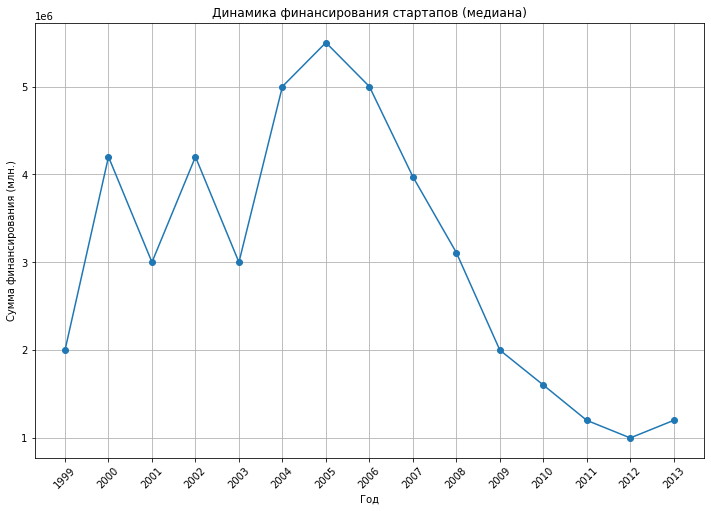

In [26]:
filter_table_invest_reset = filter_table_invest.reset_index() # сбрасываем индексы, чтобы было удобнее строить график


filter_table_invest_reset.plot(kind = 'line',
                        x = 'funded_at',
                        y = ('raised_amount', 'median'),
                        legend = False,
                        figsize = (12, 8),
                        marker = 'o')

plt.xticks(filter_table_invest_reset['funded_at'], rotation=45)

plt.grid()
plt.title('Динамика финансирования стартапов (медиана)')
plt.xlabel('Год')
plt.ylabel('Сумма финансирования (млн.)')

plt.show()

По графику видно, что:

* Больше всего средств за 1 раунд финансирования выделили в 2005 году. Среднее значение — 5 500 000. 
  Потом идет продолжительное снижение сумм финансирования до 2012 г. 
  В 2013 кривая разворачивается, но тут нельзя однозначно сказать, что начался рост средней суммы финансирования, так как нет данных за последующие года.
  
* Однако с каждым годом количество раундов увеличивается, следовательно, это может влиять на сумму одного финансирования. Тут несколько предположений:

1. Инвесторы стали выделять деньги более меньшими суммами, но чаще.
2. Инвесторы могут диверсифицировать инвестиции в разные отрасли, чтобы минимизировать риски.

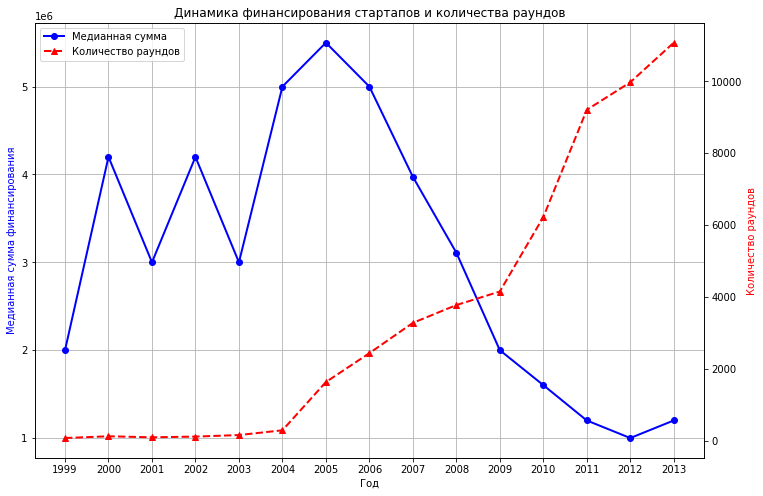

In [27]:
figure, ax1 = plt.subplots(figsize=(12, 8))

# График медианной суммы (левая ось)
ax1.plot(filter_table_invest_reset['funded_at'], 
         filter_table_invest_reset[('raised_amount', 'median')], 
         color='blue', marker='o', linewidth=2, label='Медианная сумма')
ax1.set_xlabel('Год')
ax1.set_ylabel('Медианная сумма финансирования', color = 'blue')
ax1.grid()

# Создаем вторую ось
ax2 = ax1.twinx()

# График количества раундов (правая ось)
ax2.plot(filter_table_invest_reset['funded_at'], 
         filter_table_invest_reset[('raised_amount', 'count')], 
         color='red', marker='^', linewidth=2, linestyle='--', label='Количество раундов')
ax2.set_ylabel('Количество раундов', color = 'red')


# Настройки
plt.xticks(filter_table_invest_reset['funded_at'])
plt.title('Динамика финансирования стартапов и количества раундов')

# Общая легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

Детальнее посмотрим информацию по 2013 году.

In [28]:
df_2013 = df_company_and_rounds[df_company_and_rounds['funded_at'].dt.year == 2013].copy() # создаем новый df, где финансирование за 2013г
df_2013['month'] = df_company_and_rounds['funded_at'].dt.month # добавляем новый столбец, где будет указан порядковый номер месяца.
df_2013 = df_2013[['month', 'raised_amount']] # в df  оставляем только 2 столбика

In [29]:
table_2013 = df_2013.groupby('month')['raised_amount'].agg(['count', 'median'])
table_2013['median'] = table_2013['median'].astype('int64')
table_2013

,count,median
month,,
1.0,1024,700000
2.0,740,1000000
3.0,865,750000
4.0,927,1100000
5.0,951,1037500
6.0,1039,1200000
7.0,1017,1500000
8.0,977,1000000
9.0,1064,1400000


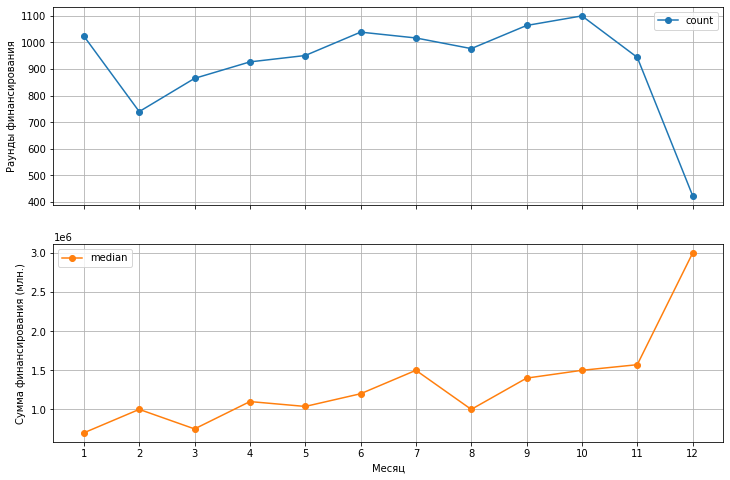

In [30]:
axes = table_2013.plot(kind = 'line',
               subplots = True,
               sharex = True,
               sharey = False,
               figsize = (12, 8),
               grid = True,
               marker = 'o')

plt.xticks(ticks = range(1, 13))

plt.xlabel('Месяц')
axes[0].set_ylabel('Раунды финансирования')
axes[1].set_ylabel('Сумма финансирования (млн.)')

plt.show()

Чаще всего в 2013 г. финансирование происходило в следующие месяца:

* январь;
* июнь;
* июль;
* сентябрь;
* октябрь (наибольшее кол-во инвестиций).

Что касается сумм, то наибольшие суммы характерны для:

* июля;
* октября;
* ноября;
* декабря (максимальные суммы за весь год).

Самыми оживленными месяцами по инвестированию (кол-во раундов и суммы) являются июль и октябрь.


### 2.2. Люди и их образование

- Оценим, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделим все компании на несколько групп по количеству сотрудников и оценим среднюю долю сотрудников без информации об образовании в каждой из групп.


In [31]:
df_people.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


In [32]:
df_education.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT


In [33]:
df_degrees.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


Датасет degrees можно присоединить, т.к. есть ID сотрудника. Однако нужно обработать данные столбца object_id, а точнее убрать приписку "р:".

In [34]:
df_degrees['object_id'] = df_degrees['object_id'].str.replace('p:', '').astype('int64')

In [35]:
df_people_education = df_people.merge(df_education, left_on = 'id', right_on = 'person_id',
                               how = 'left', suffixes = ('_employees', '_education')) # Объединим 2 датасета
df_people_education

,id_employees,first_name,last_name,company_id,network_username,id_education,person_id,instituition,graduated_at
0,10,Mark,Zuckerberg,5.0,NaN,2415.0,10.0,Harvard University,NaT
1,100,Peter,Lester,27.0,NaN,NaN,NaN,NaN,NaT
2,1000,Dr. Steven,E. Saunders,292.0,NaN,NaN,NaN,NaN,NaT
3,10000,Neil,Capel,2526.0,NaN,NaN,NaN,NaN,NaT
4,100000,Sue,Pilsch,NaN,NaN,NaN,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...
267689,99999,Ramon,Peypoch,NaN,NaN,NaN,NaN,NaN,NaT
267690,174088,Dr. Ray,Woods,188200.0,network,25958.0,174088.0,Sydney University Medical School,1982-01-01
267691,118386,Ricardo,Durand,143419.0,itechsocialnet,18871.0,118386.0,ESCS,2004-01-01
267692,175827,mahesh,kumar,NaN,socialnethubs,NaN,NaN,NaN,NaT


In [36]:
df_employees = df_people_education.merge(df_degrees, left_on = 'id_employees', right_on = 'object_id', how = 'left')

In [37]:
#len(df_employees)

In [38]:
#df_employees[df_employees['company_id'] == 1]

In [39]:
# кол-во дублей
df_employees.duplicated(subset = ['id_employees', 'first_name', 'last_name', 'person_id']).sum()

144128

In [40]:
# удаляем дубликаты
df_employees = df_employees.drop_duplicates(subset = ['id_employees', 'first_name', 'last_name', 'person_id'])

In [41]:
df_employees.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 226708 entries, 0 to 370835
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id_employees      226708 non-null  int64         
 1   first_name        226703 non-null  object        
 2   last_name         226707 non-null  object        
 3   company_id        34614 non-null   float64       
 4   network_username  38867 non-null   object        
 5   id_education      68071 non-null   float64       
 6   person_id         68071 non-null   float64       
 7   instituition      68031 non-null   object        
 8   graduated_at      36387 non-null   datetime64[ns]
 9   id                68071 non-null   float64       
 10  object_id         68071 non-null   float64       
 11  degree_type       61401 non-null   object        
 12  subject           50808 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(6)
memor

уберем столбцы `person_id` и `object_id`, т.к. они дублируют `id_employees`, и в них есть пропуски. 

In [42]:
df_employees = df_employees[['id_employees', 'first_name', 'last_name', 'company_id', 'network_username',
                            'id_education', 'instituition', 'graduated_at', 'id', 'degree_type', 'subject']]

df_employees.rename(columns = {'id': 'degree_id'})

,id_employees,first_name,last_name,company_id,network_username,id_education,instituition,graduated_at,degree_id,degree_type,subject
0,10,Mark,Zuckerberg,5.0,NaN,2415.0,Harvard University,NaT,2415.0,NaN,Computer Science
1,100,Peter,Lester,27.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,10000,Neil,Capel,2526.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,100000,Sue,Pilsch,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
370831,99999,Ramon,Peypoch,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
370832,174088,Dr. Ray,Woods,188200.0,network,25958.0,Sydney University Medical School,1982-01-01,25958.0,M.B.B.S.,Medicine
370833,118386,Ricardo,Durand,143419.0,itechsocialnet,18871.0,ESCS,2004-01-01,18871.0,PhD,Journalism
370834,175827,mahesh,kumar,NaN,socialnethubs,NaN,NaN,NaT,NaN,NaN,NaN


In [43]:
# Проверим дубли
df_employees.duplicated().sum()

0

In [44]:
pd.DataFrame({'Кол-во пропусков': df_employees.isna().sum(),
             '% пропусков': df_employees.isna().mean() * 100})

,Кол-во пропусков,% пропусков
id_employees,0,0.000000
first_name,5,0.002205
last_name,1,0.000441
company_id,192094,84.731902
network_username,187841,82.855920
id_education,158637,69.974152
instituition,158677,69.991796
graduated_at,190321,83.949839
id,158637,69.974152
degree_type,165307,72.916262


В датафрейме `df_employees` почти у 70% сотрудников нет информации об образовании.

Посмотрим на статистические метрики, возможно, что они помогут определить границы  для категорий компаний.

In [45]:
df_employees_count = df_employees.groupby('company_id', as_index = False)['id_employees'].count()
df_employees_count['id_employees'].describe(percentiles = [0.25, 0.75, 0.8, 0.9, 0.95])

count    22921.000000
mean         1.510144
std          2.764379
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
80%          2.000000
90%          2.000000
95%          4.000000
max        244.000000
Name: id_employees, dtype: float64

In [46]:
def func_count(row):
    """
    Функция подсчитывает кол-во сотрудников в компании. Работает со строками. 
    Если в строке указан id компании, то функция создает df и отбирает в него строки с одинаковым company_id, 
    а далее находит кол-во сотрудников.
    Если в company_id пропуск, то возвращает пропуск 
    """
    if not pd.isna(row['company_id']):
        group = df_employees[df_employees['company_id'] == row['company_id']]
        return group['id_employees'].count()
    else:
        return row['company_id']

df_employees['count_employees'] = df_employees.apply(func_count, axis = 1)

Так как данные неравномерно распределены, 95% компаний имеют от 4 и менее сотрудников, но есть и компании со штатом 244 человека, то:

* вначале будет дробить на группы, в которых будет несколько человек;
* после 95% процентиля будет дробить на группы, в которые входят несколько десятков сотрудников.

In [47]:
df_employees['categories_companies'] = pd.cut(df_employees['count_employees'],
                                             bins = [0, 1, 2, 4, 7, 10, 20, 50, 100, float('inf')],
                                             labels = ['1 сотрудник', '2 сотрудника', '3-4 сотрудника', '5-7 сотрудников',
                                                       '8-10 сотрудников', '11-20 сотрудников', '21-50 сотрудников',
                                                      '51-100 сотрудников', 'более 100 сотрудников'])

In [48]:
df_employees['is_missing'] = df_employees['id_education'].isna()
print('Доля сотрудников, у которых нет информации об образовании:')
df_employees.groupby('categories_companies')['is_missing'].mean()

Доля сотрудников, у которых нет информации об образовании:


categories_companies
1 сотрудник              0.462575
2 сотрудника             0.466039
3-4 сотрудника           0.486084
5-7 сотрудников          0.521563
8-10 сотрудников         0.549296
11-20 сотрудников        0.458197
21-50 сотрудников        0.312388
51-100 сотрудников       0.284123
более 100 сотрудников    0.287594
Name: is_missing, dtype: float64

In [49]:
df_employees['categories_companies'].value_counts()

1 сотрудник              18116
2 сотрудника              5418
3-4 сотрудника            4563
5-7 сотрудников           2713
11-20 сотрудников         1220
8-10 сотрудников          1136
21-50 сотрудников          557
более 100 сотрудников      532
51-100 сотрудников         359
Name: categories_companies, dtype: int64

Из проведенного анализа видно, что наибольшая доля сотрудников, у которых нет информации об образовании, работает в компаниях с маленькой численностью. 
Здесь можно предположить, что когда стартап только начинает работать, то у него небольшая численность штата и приоритет отдаются другим критериям, а не образованию, а вот когда численность сотрудников растет, то образование начинает играть более весомую роль.


Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.

Проверим, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием


Столбец `network_username` встречается в датасетах: `people` и `company_and_rounds`. Проверим, какие данные там содержатся.

In [50]:
df_company_and_rounds['network_username'] = df_company_and_rounds['network_username'].str.lower().str.strip()

In [51]:
# Проверим, есть ли общие никнеймы
common_usernames = set(df_company_and_rounds['network_username']) & set(df_people['network_username'])
print(f"Общие никнеймы: {len(common_usernames)}")

# Посмотрим примеры
if common_usernames:
    print("Примеры общих никнеймов:", list(common_usernames))
else:
    print("Нет пересечений")

Общие никнеймы: 1804
Примеры общих никнеймов: [nan, 'masschallenge', 'localfoodsys', 'investocontra', 'mayonstudios', 'accuracast', 'mastertipper007', 'spicy_spirit', 'mizecom', 'althafrahman', 'tagionet', 'amirkhella', 'xhtml', 'memorybistro', 'jordanenglish', 'rprosen', 'mr1elee', 'alibhamed', 'amanda_hill', 'rwandatours', 'mindahome', 'tifflyindia', 'younationwide', 'evvnt', 'viastudios', 'bigbluehat', 'dlolimousine', 'thebarcodenews', 'give2gether', 'sparqlight', 'tradiart', 'gocubby', 'lmgpr', 'wavlite', 'timesofnet', 'intellibank', 'firmaffiliate', 'snoopff', 'rafflecopter', 'jnisby', 'lonroth', 'clouds_media', 'itmonteur', 'travelstreetuk', 'hunome', 'mind_update', 'play_tank', 'uggnohnuy', 'mikeford', 'bandsonabudget', 'inspectlet', 'cheapohnetwork', 'fitblazeapp', 'pragermicro', 'bespokeapp', 'tyrabanks', 'noisetrend', 'bathroomsigns', 'johndevor', 'dupageattorneys', 'niyati', 'pofx_adagency', 'hirephpcom', 'studentfunder', 'cofounderslab', 'anteksiler', 'jefftopia', 'ziller_w

In [52]:
# для проверки
df_company_and_rounds[df_company_and_rounds['network_username'] == 'yumedeals3']

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
39921,176105.0,Yume traders india,ecommerce,operating,2009-01-03,NaT,yumeindia.com,yumedeals3,IND,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# для проверки
df_people[df_people['network_username'] == 'yumedeals3']

,id,first_name,last_name,company_id,network_username
49279,160702,Vinod,Reddy,NaN,yumedeals3


1803 никнейма совпадаю, однако не вижу смыла их объединять , так как в `df_people` указывается ник человека / сотрудника.

А в `df_company_and_rounds` - ник компании. Да и нелогично объединять эти датасеты, так как там содержится информация разного рода.

Есть еще дополнительный датасет `fund`, который содержит информацию о фондах, возможно, что его можно будет объединить с `df_company_and_rounds`.

In [54]:
df_fund = pd.read_csv('https://code.s3.yandex.net/datasets/fund.csv')
df_fund.head()

,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


In [55]:
df_fund.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11650 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB


In [56]:
df_fund['network_username'] = df_fund['network_username'].str.lower().str.strip()

In [57]:
# Проверим, есть ли общие никнеймы
common_usernames = set(df_company_and_rounds['network_username']) & set(df_fund['network_username'])
print(f"Общие никнеймы: {len(common_usernames)}")

# Посмотрим примеры
if common_usernames: 
    print("Примеры общих никнеймов:", list(common_usernames))
else: # 
    print("Нет пересечений")

Общие никнеймы: 88
Примеры общих никнеймов: [nan, 'novonordisk', 'gridleyco', 'harmannews', 'creditsuisse', 'lenduploans', 'morningstarinc', 'choosewhat', 'yearonelabs', 'kiicorp', 'syngenta', 'swisscom', 'intertrusttech', 'thomsonreuters', 'transfirst', 'citynetwork', 'alcatel_lucent', 'capital_direct', 'wwt_inc', 'masscec', 'startupgenome', 'txtloan', 'flextronics', 'nyuniversity', 'hummingbirdvc', 'annprbuongiorno', 'goparti', 'accion_global', 'launchhausfc', 'motorola', 'switchcommerce', 'priceride', 'ndrc_i2i', 'abnamro', 'vcet', 'slicktext', 'standardbankgrp', 'jumpstartinc', 'tefdigital', 'dgillesfr', 'galaxyphotoz', 'rovicorp', 'comparefx', 'dowchemical', 'berkerymanda', 'chevron', 'seoworks', 'zestfinance', 'blackstone', 'telus', 'yumedeals3', 'globalreachp', 'lek_consulting', 'angel__network', 'stockholmprecis', 'ifmrtrust', 'bpifrance', 'tradekey', 'bessemervp', 'playboy', 'sparklabsinc', 'just_dial', 'boonseo', 'yscapital', 'enlabs', 'atlassian', 'gearylsf', 'siamosoci', 'h

In [58]:
# для проверки
df_company_and_rounds[df_company_and_rounds['network_username'] == 'morningstarinc']

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
149118,28285.0,Morningstar,software,ipo,1984-01-01,NaT,morningstar.com,morningstarinc,USA,4.0,...,2.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
# для проверки
df_fund[df_fund['network_username'] == 'morningstarinc']

,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
6451,3698,Morningstar Japan,1980-01-01,morningstar.com,morningstarinc,JPN,1,1,0


Между датасетами `df_company_and_rounds` и `df_fund` есть пересечения по никам, но их всего 87. 
Проверил часть никнеймов, и в основном в `df_company_and_rounds` с таким ником встречается 1 компания. Тут можно их объединить по никам, но особой пользы от этого не вижу, т. к. крайне мало пересечений.


### 2.3. Проблемный датасет и причина возникновения пропусков

Больше всего вопросов к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая важна.


In [60]:
df_company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_ID           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [61]:
df_company_and_rounds.head(15)

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
7,10002.0,Synergie Media,advertising,operating,2007-06-27,NaT,synergie-media.com,NaN,MAR,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
8,10003.0,Green Basti Ecosystems,cleantech,operating,2008-08-20,NaT,NaN,NaN,IND,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
9,100042.0,HostNine,NaN,operating,NaT,NaT,hostnine.com,hostnine,NaN,0.0,...,1.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
#df_company_and_rounds[df_company_and_rounds['name'] == 'wetpaint']

In [63]:
# Нормализуем строковыне данные
for col in ['name', 'category_code', 'status', 'domain', 'network_username', 'country_code', 'funding_round_type']:
    df_company_and_rounds[col] = df_company_and_rounds[col].str.lower().str.strip()

Столбци `funding_total` и `raised_amount` похоже. Однако здесь можно предположить, что в `funding_total` содержится общая сумма всех финансирований компании, а в `raised_amount` указывается отдельно каждая сумма.

In [64]:
df_company_and_rounds[['investment_rounds', 'funding_rounds']].head(15)

,investment_rounds,funding_rounds
0,0.0,3.0
1,0.0,3.0
2,0.0,3.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,0.0


In [65]:
# проверим значения, если будут 0, то можно будет удалить
df_company_and_rounds['investment_rounds'].unique()

array([  0.,   1.,   3.,  32.,   2.,   4.,   9.,  30.,  17.,   7.,   6.,
         8.,  18.,   5.,  25.,  19.,  49.,  21.,  16.,  14.,  37.,  96.,
        22.,  10.,  12., 478.,  15.,  89.,  11.,  24., 297.,  20.,  29.,
       125.,  33.,  40.,  38.,  68.,  13.,  44.,  58.,  51.,  nan])

`investment_rounds` и `funding_rounds` схожи по смыслу, но на данный момент нельзя понять, чем они отличаются.

In [66]:
# df_company_and_rounds

Проверим информацию в `is_first_round` и `is_last_round`.

In [67]:
df_company_and_rounds[~(df_company_and_rounds['is_first_round'].isna())].head(30)

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
15,1001.0,friendfeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,usa,0.0,...,3.0,1644.0,1001.0,2008-02-26,series-a,5000000.0,0.0,3.0,1.0,1.0
20,10014.0,mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,usa,0.0,...,4.0,6682.0,10014.0,2008-09-01,angel,0.0,0.0,1.0,1.0,1.0
21,10015.0,fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,usa,0.0,...,0.0,3619.0,10015.0,2008-10-10,series-a,2000000.0,0.0,2.0,0.0,1.0
22,10015.0,fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,usa,0.0,...,0.0,18213.0,10015.0,2010-09-10,series-b,9000000.0,0.0,4.0,0.0,0.0
23,10015.0,fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,usa,0.0,...,0.0,27747.0,10015.0,2012-01-24,series-c+,12000000.0,0.0,4.0,0.0,0.0
24,10015.0,fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,usa,0.0,...,0.0,45409.0,10015.0,2013-08-13,series-c+,43000000.0,0.0,5.0,1.0,0.0
25,10015.0,fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,usa,0.0,...,0.0,54006.0,10015.0,2012-01-01,venture,2069200.0,0.0,4.0,0.0,0.0


In [68]:
# для точечной проверки 
#df_company_and_rounds[df_company_and_rounds['name'] == 'cardiosolutions']

Столбцы перепутаны, т. е. на данный момент, если раунд является первым, то в `is_first_round` стоит 0, а в `is_last_round` - 1, и наоборот. Поменяем названия, чтобы значения в этих столбцах были более логичны.

In [69]:
df_company_and_rounds = df_company_and_rounds.rename(columns = {'is_first_round': 'is_last_round',
                                                              'is_last_round': 'is_first_round'})

In [70]:
# для точечной проверки 
# df_company_and_rounds[df_company_and_rounds['name'] == 'fitbit']

In [71]:
# поменяем столбцы местами

# Получить список всех столбцов
cols = df_company_and_rounds.columns.tolist()

# Найти индексы столбцов, которые нужно поменять
idx_a = cols.index('is_last_round')
idx_b = cols.index('is_first_round')

# Поменять их местами в списке
cols[idx_a], cols[idx_b] = cols[idx_b], cols[idx_a]

# Применить новый порядок
df_company_and_rounds = df_company_and_rounds[cols]

# df_company_and_rounds

In [72]:
# проверяем дубли
df_company_and_rounds.duplicated().sum()

0

Проверим строки, где пропуски в `company_ID`.

In [73]:
df_company_and_rounds[(df_company_and_rounds['company_ID'].isna())]

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
217472,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,457.0,1267.0,2005-01-01,series-a,48000000.0,0.0,2.0,1.0,1.0
217473,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,471.0,558.0,2007-01-01,angel,300000.0,0.0,1.0,1.0,1.0
217474,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,575.0,746.0,2004-09-01,angel,0.0,0.0,0.0,1.0,1.0
217475,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,577.0,748.0,2007-01-01,series-a,1500000.0,2250000.0,0.0,1.0,1.0
217476,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,597.0,804.0,2007-06-01,series-a,6000000.0,0.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56454.0,282847.0,2011-01-31,other,5500000.0,0.0,0.0,1.0,1.0
217770,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56542.0,55477.0,2011-01-13,venture,10633300.0,0.0,0.0,1.0,0.0
217771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56543.0,55477.0,2012-05-31,venture,2125720.0,0.0,0.0,0.0,1.0
217772,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56928.0,283492.0,2013-12-03,venture,3602480.0,0.0,5.0,1.0,1.0


Можно было удалить строки, где в `company_ID` пропуски, т.к. отсутствует информация о компаниях, но оставим их, т.к. цель - сохранить как можно больше данных, плюс эти данные могут пригодиться, если будем анализировать типы финансирования и суммы.

Датасет `df_company_and_rounds` оказался низкого качества, т.к. много пропусков, есть столбцы, которые дублируют друг друга, и столбцы, которые перепутаны местами.

Возможно, что этот датасет собран из других датасетов, это как раз могло объяснить такое качество.

In [74]:
df_company_and_rounds.head()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,1.0,0.0
1,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,0.0,1.0
3,10.0,flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,usa,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,there,games_video,acquired,NaT,NaT,there.com,NaN,usa,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
# объясвим df_company

company_columns = ['company_ID', 'name', 'category_code', 'status', 'founded_at', 'closed_at', 
                  'domain', 'network_username', 'country_code', 'investment_rounds', 'funding_rounds',
                  'funding_total', 'milestones']

df_company = df_company_and_rounds[company_columns]

print(f'Количество дублей: {df_company.duplicated().sum()}')

Количество дублей: 21220


In [76]:
# удялем дубли

df_company = df_company.drop_duplicates(keep = 'first', inplace = False)
print(f'Кол-во строк в df_company - {df_company.shape[0]}')
df_company

Кол-во строк в df_company - 196554


,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,3.0,39750000.0,5.0
3,10.0,flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,usa,0.0,0.0,0.0,0.0
4,100.0,there,games_video,acquired,NaT,NaT,there.com,NaN,usa,0.0,0.0,0.0,4.0
5,10000.0,mywebbo,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,0.0,0.0,0.0
6,10001.0,the movie streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217463,3429.0,zend technologies,software,operating,1999-01-01,NaT,zend.com,networkzend,usa,0.0,4.0,44000000.0,6.0
217467,7748.0,flowgram,web,closed,2007-06-01,2008-06-11,flowgram.com,network,usa,0.0,1.0,1300000.0,3.0
217468,174536.0,pphotonet,games_video,operating,2012-05-01,NaT,pphotonet.co,pphotonet,NaN,0.0,0.0,0.0,0.0
217469,43233.0,photonet,photo_video,acquired,2010-03-01,NaT,photonet.com,photonet,usa,0.0,3.0,57500000.0,3.0


In [77]:
# объявим df_round

round_columns = ['funding_round_id', 'company_id', 'funded_at', 'funding_round_type',
                'raised_amount', 'pre_money_valuation', 'participants', 'is_first_round', 'is_last_round']

df_round = df_company_and_rounds[round_columns]

print(f'Количество дублей: {df_round.duplicated().sum()}')

Количество дублей: 164845


In [78]:
df_round = df_round.drop_duplicates()
df_round

,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,1.0,0.0
1,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,0.0,1.0
3,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
15,1644.0,1001.0,2008-02-26,series-a,5000000.0,0.0,3.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...
217769,56454.0,282847.0,2011-01-31,other,5500000.0,0.0,0.0,1.0,1.0
217770,56542.0,55477.0,2011-01-13,venture,10633300.0,0.0,0.0,1.0,0.0
217771,56543.0,55477.0,2012-05-31,venture,2125720.0,0.0,0.0,0.0,1.0
217772,56928.0,283492.0,2013-12-03,venture,3602480.0,0.0,5.0,1.0,1.0


### ## Шаг 3. Исследовательский анализ объединённых таблиц




### 3.1. Объединение данных


In [79]:
df_company.head()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,3.0,39750000.0,5.0
3,10.0,flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,usa,0.0,0.0,0.0,0.0
4,100.0,there,games_video,acquired,NaT,NaT,there.com,NaN,usa,0.0,0.0,0.0,4.0
5,10000.0,mywebbo,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,0.0,0.0,0.0
6,10001.0,the movie streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,0.0,0.0,0.0


In [80]:
df_company.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196554 entries, 0 to 217472
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_ID         196553 non-null  float64       
 1   name               196553 non-null  object        
 2   category_code      123186 non-null  object        
 3   status             196553 non-null  object        
 4   founded_at         91227 non-null   datetime64[ns]
 5   closed_at          2620 non-null    datetime64[ns]
 6   domain             126545 non-null  object        
 7   network_username   80591 non-null   object        
 8   country_code       87990 non-null   object        
 9   investment_rounds  196553 non-null  float64       
 10  funding_rounds     196553 non-null  float64       
 11  funding_total      196553 non-null  float64       
 12  milestones         196553 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)


In [81]:
# объявляем новый датасет согласно условиям задания
df = df_company[(df_company['investment_rounds'] > 0) | 
                (df_company['funding_rounds'] > 0) |
                (df_company['status'] == 'acquired')]

In [82]:
print(f'Датасет df содержит {df.shape[0]} строк')

Датасет df содержит 40747 строк


In [83]:
#df['status'].value_counts()


### 3.2. Анализ выбросов


Посмотрим на статистические характеристики:

In [84]:

df['funding_total'].describe().astype('int64')

count         40747
mean       10135609
std        56464359
min               0
25%               0
50%          600000
75%         5650650
max      5700000000
Name: funding_total, dtype: int64

По полученным значениям можно сделать следующие выводы:

* у значений в столбце `funding_total` большой разброс данных, об этом говорит разница между средним арифметическим и медианой. Стандартное отклонение тоже подтверждает это.
* максимальное значение составляет 5 700 000 000. На данный момент сложно судить о корректности этой цифры. Вполне возможно, что такое финансирование может быть, так как бывают разные стартапы, которые требуют разного финансирования.

Если в дальнейшем будет использовать данные из `funding_total` для нахождения средних значений, то лучше использовать медиану, т.к. она менее подвержена выбросам.

Посмотрим гистограмму и изучим ее, она позволит увидеть часто встречающиеся значения.

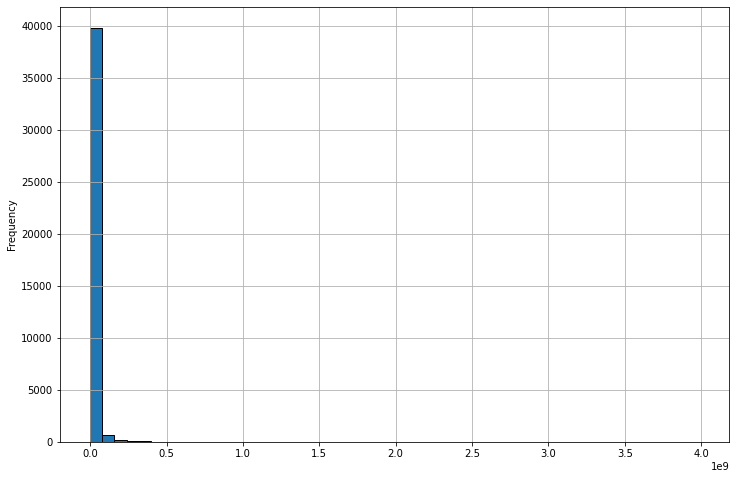

In [85]:
plt.figure(figsize = (12, 8))

df[df['funding_total'] < 5700000000]['funding_total'].plot(kind = 'hist',
                        bins = 50,
                        edgecolor = 'black')

plt.grid()

plt.show()

Из-за сильного разброса гистограмма получается неинформативной. Попробуй убрать нулевые инвестиции.

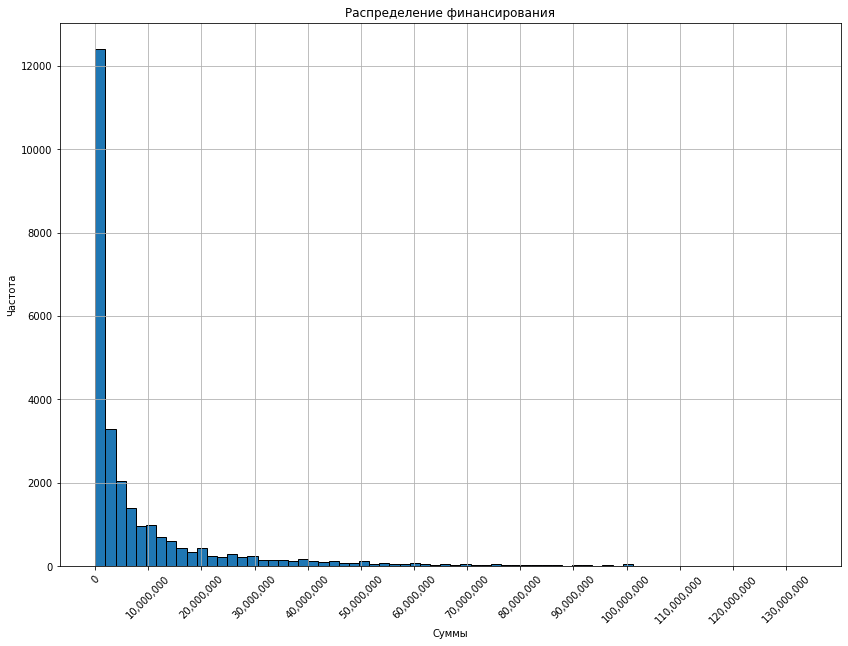

In [86]:
import matplotlib.ticker as ticker

quan_25 = df['funding_total'].quantile(0.25)
quan_99 = df['funding_total'].quantile(0.99)
df_filter_hist = df[(df['funding_total'] > quan_25) & 
                   (df['funding_total'] < quan_99)]



plt.figure(figsize = (14, 10))

df_filter_hist['funding_total'].plot(kind = 'hist',
                                    bins = 70,
                                    edgecolor = 'black',
                                    rot = 45)

plt.grid()
plt.title('Распределение финансирования')
plt.xlabel('Суммы')
plt.ylabel('Частота')

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

x_min = 0
x_max = int(df_filter_hist['funding_total'].max())

ticks = range(x_min, x_max + 1000000, 10000000)
plt.xticks(ticks)


plt.show()

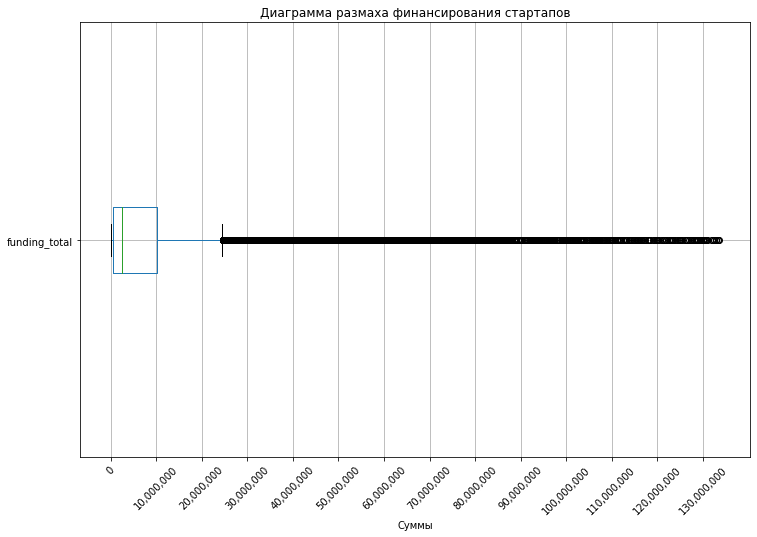

In [87]:
plt.figure(figsize = (12, 8))

df_filter_hist.boxplot(column = 'funding_total',
          vert = False)

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Диаграмма размаха финансирования стартапов')
plt.xlabel('Суммы')

x_min = 0
x_max = int(df_filter_hist['funding_total'].max())

ticks = range(x_min, x_max + 1000000, 10000000)
plt.xticks(ticks, rotation = 45)


plt.show()

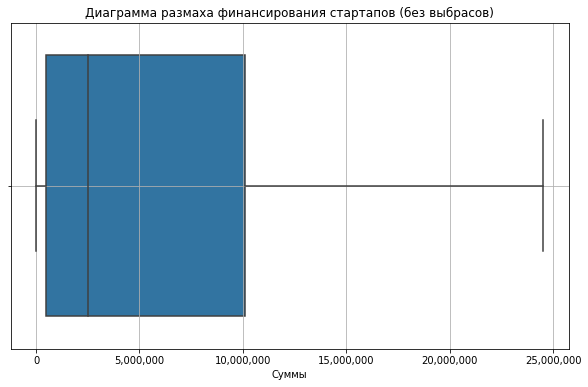

In [88]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df_filter_hist,
           x= 'funding_total',
           showfliers=False)

plt.grid()
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Диаграмма размаха финансирования стартапов (без выбрасов)')
plt.xlabel('Суммы')

plt.show()

In [89]:
df_filter_hist['funding_total'].describe().astype('int64')

count        27466
mean      10086339
std       18600169
min            291
25%         500000
50%        2500000
75%       10115875
max      133663000
Name: funding_total, dtype: int64

По итогам изучения диаграмм можно сделать следующие выводы:

* чаще всего встречаются финансирования до 10 млн;
* финансирования свыше 24 млн считаются выбросами, но их все же не стоит исключать, т. к. большие суммы финансирования тоже могут быть.


### 3.3. Куплены забесплатно?

- Исследуем компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.


In [90]:
# df_acquisition[df_acquisition['price_amount'] == 1]

In [91]:
# df[df['company_ID'] == 283073]

In [92]:
df_buy = df.merge(df_acquisition,
                  left_on = 'company_ID', right_on = 'acquired_id',
                  how = 'left')
df_buy.head()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,id,acquiring_id,acquired_id,term_code,price_amount,acquired_at
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,3.0,39750000.0,5.0,NaN,NaN,NaN,NaN,NaN,NaT
1,10.0,flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,usa,0.0,0.0,0.0,0.0,1.0,11.0,10.0,NaN,20000000.0,2007-05-30
2,100.0,there,games_video,acquired,NaT,NaT,there.com,NaN,usa,0.0,0.0,0.0,4.0,20.0,377.0,100.0,cash,0.0,2005-05-29
3,1001.0,friendfeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,usa,0.0,1.0,5000000.0,3.0,1901.0,5.0,1001.0,cash_and_stock,47500000.0,2009-08-10
4,10014.0,mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,usa,0.0,1.0,0.0,4.0,3878.0,23054.0,10014.0,NaN,0.0,2010-09-30


In [93]:
#df_buy['price_amount'] = df_buy['price_amount'].apply(lambda x: f"{x:,.0f}")
#df_buy[df_buy.duplicated(subset = 'company_ID', keep = False)].sort_values(by = 'company_ID').head(14)

In [94]:
#df_fund[df_fund['id'] == 1242]

In [95]:
df_buy = df_buy[(df_buy['funding_total'] > 0) &
               (df_buy['price_amount'] <= 1)]
df_buy

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,id,acquiring_id,acquired_id,term_code,price_amount,acquired_at
25,10054.0,jumptap,mobile,acquired,2005-01-01,NaT,jumptap.com,jumptap,usa,0.0,7.0,121500000.0,3.0,9288.0,23283.0,10054.0,cash_and_stock,0.0,2013-08-13
63,101312.0,sidetour,web,acquired,2011-06-01,NaT,sidetour.com,sidetour,usa,0.0,3.0,4000000.0,2.0,9653.0,11391.0,101312.0,NaN,0.0,2013-09-18
66,101340.0,choicepass,enterprise,acquired,2011-07-01,NaT,choicepass.com,choicepass,usa,0.0,1.0,250000.0,1.0,7272.0,1972.0,101340.0,NaN,0.0,2012-06-18
67,10137.0,producteev,software,acquired,2008-07-08,NaT,producteev.com,producteev,usa,0.0,3.0,1310000.0,2.0,8254.0,757.0,10137.0,cash_and_stock,0.0,2012-11-05
68,10139.0,tradecard,enterprise,acquired,1999-01-01,NaT,tradecard.com,tradecard,usa,0.0,2.0,44925000.0,1.0,9326.0,44008.0,10139.0,NaN,0.0,2013-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40834,99.0,amie street,web,acquired,2011-07-04,NaT,amiestreet.com,amiestreet_logs,usa,0.0,2.0,3900000.0,0.0,7024.0,317.0,99.0,NaN,0.0,2010-09-22
40836,9905.0,ubmatrix,software,acquired,2005-01-01,NaT,ubmatrix.com,NaN,usa,0.0,2.0,5172350.0,0.0,3381.0,41119.0,9905.0,NaN,0.0,2010-06-24
40840,992.0,wunderloop,advertising,acquired,1999-01-01,NaT,wunderloop.com,NaN,usa,0.0,1.0,10000000.0,1.0,9916.0,19182.0,992.0,NaN,0.0,2010-07-02
40854,997.0,zimbra,enterprise,acquired,2003-01-01,NaT,zimbra.com,zimbra,usa,0.0,1.0,14500000.0,3.0,9121.0,415.0,997.0,NaN,0.0,2013-07-15


In [96]:
df_buy = df_buy.drop_duplicates(subset = 'company_ID', inplace = False)

In [97]:
df_buy['funding_total'].describe().astype('int64')

count          1593
mean       17989939
std       145312235
min            3750
25%         2000000
50%         6000000
75%        15400000
max      5700000000
Name: funding_total, dtype: int64

Рассчитаем границы выбросов графически и аналитически.

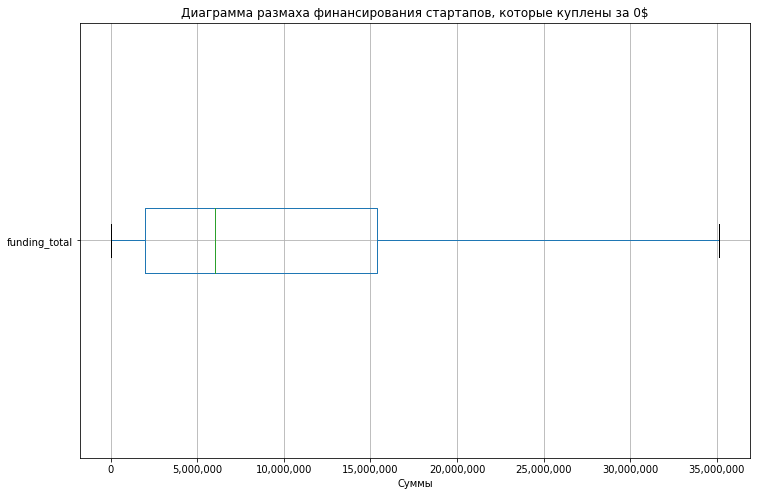

In [98]:
plt.figure(figsize = (12, 8))

df_buy.boxplot(column = 'funding_total',
               vert = False,
              showfliers = False)

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Диаграмма размаха финансирования стартапов, которые куплены за 0$')
plt.xlabel('Суммы')


plt.show()

In [99]:
q1 = df_buy['funding_total'].quantile(0.25) # 25-й процентиль
q3 = df_buy['funding_total'].quantile(0.75) # 75-й процентиль

iqr = q3 - q1 # межквартильный размах

lower = q1 - 1.5 * iqr # нижняя граница
upper = q3 + 1.5 * iqr # верхняя граница

lower_percentile = int((df['funding_total'] <= lower).mean() * 100)
upper_percentile = round((df['funding_total'] >= upper).mean() * 100, 2)

print(f'нижняя граница: {lower}\nверхня граница: {upper}')
print()
print(f'процентиль нижней границы: {lower_percentile}\nпроцентиль верхней границы: {upper_percentile}')

нижняя граница: -18100000.0
верхня граница: 35500000.0

процентиль нижней границы: 0
процентиль верхней границы: 6.34


Верхняя граница, что при графическом, что при аналитическом подсчете, совпадают.

При аналитическом подсчете нижняя граница получилась отрицательной, могу предположить, что это связано с ассиметричным распределением данных. В жизни финансирование не может быть отрицательным. Нижняя граница на графике выглядит более привычнее.

0% компаний получили отрицательное финансирование, что логично.

6,3% компаний получают аномально большие финансирования.


### 3.4. Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделим категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.


In [100]:
df_over_price = df.merge(df_acquisition,
                  left_on = 'company_ID', right_on = 'acquired_id',
                  how = 'inner') # исполльзуем inner, чтобы оставить только стартапы, которые были проданы


In [101]:
# отфильтруем и уберем стартапы, где цена покупки = 0, т.к. из-за этого медиана у большинства категорий = 0.
df_over_price = df_over_price[df_over_price['price_amount'] > 0]

In [102]:
df_over_price['category_code'].value_counts()

software            403
biotech             263
web                 260
mobile              117
enterprise          116
games_video          88
advertising          84
other                84
hardware             78
public_relations     74
semiconductor        71
network_hosting      64
ecommerce            50
cleantech            39
security             36
consulting           32
manufacturing        21
finance              20
search               19
health               10
news                  9
hospitality           7
education             6
real_estate           6
messaging             5
photo_video           5
social                4
travel                4
medical               4
music                 3
transportation        3
automotive            3
fashion               3
analytics             3
sports                2
local                 1
nanotech              1
Name: category_code, dtype: int64

In [103]:
#len(df_over_price['category_code'].value_counts())

Достаточно много категорий стартапов, возьмем только те, которые встречаются более 50 раз. 
Берем с частотой более 50 по причинам: 

* дают больше данных для анализа;
* единичные или редкие категории могут исказить анализ

In [104]:
over_50 = df_over_price['category_code'].value_counts()
category_over_50 = over_50[over_50 >= 50].index.tolist()
percentile_99 = df_over_price['price_amount'].quantile(0.99) # bсключаем выбросы, так как тепловая карта получалась неинформативной из-за аномальных значений, которые были в категории enterprise.

df_filter = df_over_price[(df_over_price['category_code'].isin(category_over_50)) &
                         (df_over_price['price_amount'] <= percentile_99)]
df_filter['category_code'].value_counts()

software            398
web                 260
biotech             257
mobile              116
enterprise          114
games_video          87
advertising          84
other                83
hardware             78
semiconductor        71
public_relations     70
network_hosting      64
ecommerce            50
Name: category_code, dtype: int64

In [105]:
#df_filter.head()

In [106]:
#df_filter['price_amount'] = df_filter['price_amount'].astype('int64')

In [107]:
pivot_df  = pd.pivot_table(df_filter,
              index = 'category_code',
              values = 'price_amount',
              aggfunc = ['mean', 'median', 'std'])



In [108]:
#pivot_df

В стартапах с категорией `enterprise` есть аномально большие значения, т. к. сильно отличаются медиана и среднее арифметическое, и большое стандартное отклонение. Тепловая карта получилась неинформативной.

Ниже карта уже без аномальных значений.

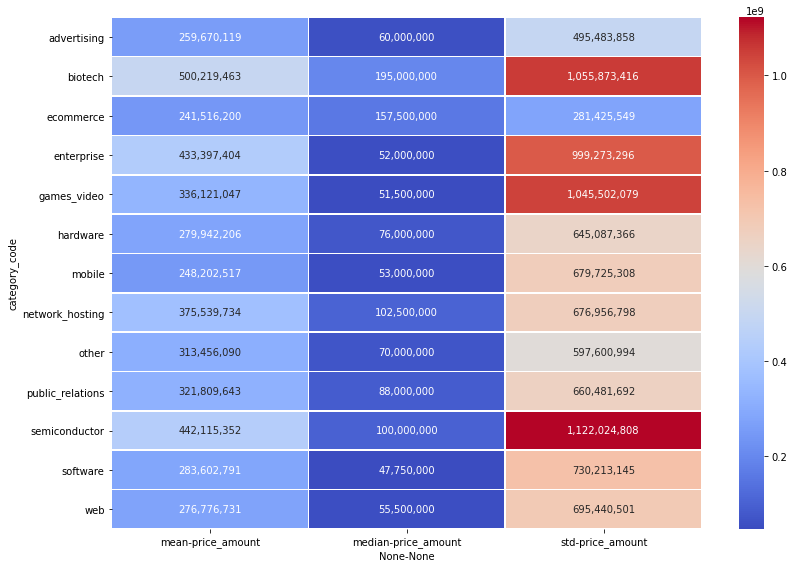

In [109]:
plt.subplots(figsize=(12, 8))

sns.heatmap(pivot_df,
           annot = True,
           fmt = ',.0f',
           cmap = 'coolwarm',
           linewidth = 0.5)

plt.tight_layout()
plt.show()

Выделим ТОП-4 категории, для которых характерны высокие цены и большой разброс:

1. `biotech`
2. `semiconductor`
3. `enterprice`
4. `games-video` 

4 категории, т.к. последние идут плотно.

In [110]:
#df_enterprise = df_filter[df_filter['category_code'] == 'enterprise']
#df_enterprise['price_amount'].describe().astype('int64')


### 3.5. Сколько раундов продержится стартап перед покупкой


In [111]:
df.head()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,bachelrwetpaint,usa,0.0,3.0,39750000.0,5.0
3,10.0,flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,usa,0.0,0.0,0.0,0.0
4,100.0,there,games_video,acquired,NaT,NaT,there.com,NaN,usa,0.0,0.0,0.0,4.0
15,1001.0,friendfeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,usa,0.0,1.0,5000000.0,3.0
20,10014.0,mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,usa,0.0,1.0,0.0,4.0


In [112]:
df['status'].value_counts()

operating    28621
acquired      9394
closed        2092
ipo            640
Name: status, dtype: int64

У нас есть 4 возможных статуса:

* operating    
* acquired      
* closed        
* ipo     


In [113]:
df_startup = df
#df_startup.info()

In [114]:
pd.DataFrame({'Кол-во раундов': df_startup['funding_rounds'].value_counts(),
              'Процент раундов': df_startup['funding_rounds'].value_counts(normalize = True) * 100})

,Кол-во раундов,Процент раундов
1.0,20534,50.393894
0.0,9040,22.185682
2.0,6142,15.073502
3.0,2662,6.532996
4.0,1216,2.984269
5.0,600,1.472501
6.0,249,0.611088
7.0,147,0.360763
8.0,67,0.164429
9.0,46,0.112892


In [115]:
df_startup['funding_rounds'].describe()

count    40747.000000
mean         1.291531
std          1.264604
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         15.000000
Name: funding_rounds, dtype: float64

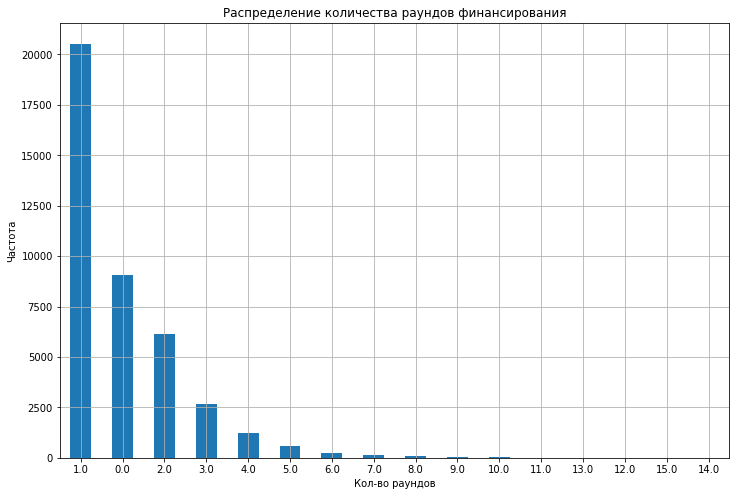

In [116]:
plt.figure(figsize = (12, 8))

df_startup['funding_rounds'].value_counts().plot(kind = 'bar',
                                        rot = 0)

plt.grid()
plt.title('Распределение количества раундов финансирования')
plt.xlabel('Кол-во раундов')
plt.ylabel('Частота')

plt.show()

Промежуточные итоги по всем стартапам:

* 50% стартапов продавались после 1 раунда финансирования, а 22% вообще без финансрования
* Можно сделать вывод, что компании покупались почти сразу или после 1–2 раундов.
* Максимальное количество раундов — 15.

Проанализируем срднее количество раундов для каждого статуса.

In [117]:
 group = df_startup.groupby('status')['funding_rounds'].mean()

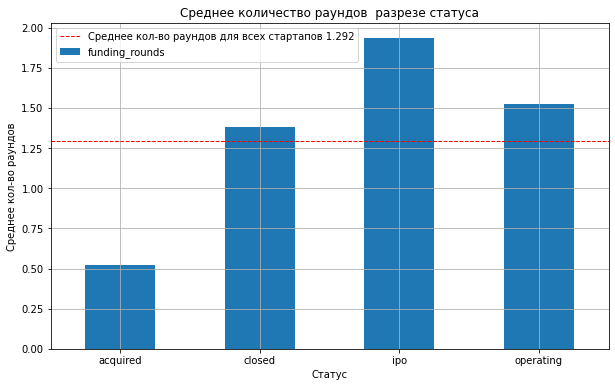

In [118]:
plt.figure(figsize = (10, 6))

group.plot(kind = 'bar',
          rot = 0)

mean_funding_rounds = round(df_startup['funding_rounds'].mean(), 3)

plt.axhline(mean_funding_rounds,
           color = 'red',
           linestyle = '--',
           linewidth = 1,
           label = f'Среднее кол-во раундов для всех стартапов {mean_funding_rounds}')

plt.grid()
plt.legend()
plt.title('Среднее количество раундов  разрезе статуса')
plt.xlabel('Статус')
plt.ylabel('Среднее кол-во раундов')

plt.show()

In [119]:
#df_startup[df_startup['status'] == 'closed']

Чаще всего финансирования получают стартапы со статусом IPO. Потом идут со статусом closed и меньше всего для компаний в статусе acquired.



## Шаг 4. Итоговый вывод и рекомендации


Анализ состоял из нескольких этапов:

* загрузка данных и первичное знакомство с ними;
* предобработка;
* исследовательский анализ;
* формулировка выводов.
  
  В ходе исследования были проанализированы данные о финансировании стартапов. Данные были представлены в нескольких датасетах:


* информация о покупках компаний;
* информация о самих компаниях и раундах инвестирования;
* информация о сотрудниках.

Один из ключевых датасетов `df_company_and_rounds` был плохого качества, с большим количеством пропусков, некоторые столбцы дублировали друг друга. Причина была в том, что это был уже объединенный датасет. В рамках исследовательского анализа он был разделен на 2 датасета.

В ходе 2 этапа «Предварительная обработка и предварительный анализ» были выявлены следующие особенности:

* Суммы финансирования имеют большой разброс.
* С каждым годом средняя сумма финансирования имеет тенденцию на снижение, но росло количество раундов финансирования.
* Детально посмотрели информацию по 2013г.
  Самыми активными месяца в плане инвестирования были июль и октябрь 
* В основном (в 95%) в компаниях числится 4 сотрудника. 
  Была найдена тенденция, что наибольшая доля сотрудников, у которых нет информации об образовании, работает в компаниях с маленькой численностью, и наоборот, чем больше компании, тем больше у них сотрудников с информацией об образовании.
* для объединения датасетов лучше использовать id компании. 
* `df_company_and_rounds` был разделен на 2 датасета: `df_company` (с информацией о компаниях) и `df_round` (с информацией о раундах).

3 этап "Исследовательский анализ"

* `funding_total` (общая сумма финансирования) имеет большой разброс. 
  Это может говорить о том, что необязательно иметь большой капитал, чтобы стать инвестором.

  И чаще инвестирую относительно небольшие суммы.
* Есть стартапы, которые были куплены за 0$. Здесь можно предположить, что между инвестором и стартапом есть договоренность на определенную сумму инвестиций, а далее стартап продается за символическую сумму, либо это может быть какое-то слияние. Эта гипотеза, которая требует дополнительной проверки.

Аномально большое финансирование получает приблизительно 6% компаний.

* Для крупных инвестиций можно присмотреться к компаниям из следующих областей: biotech, semiconductor, enterprice и games-video.
* В основном стартапы покупаются сразу, без финансирования, или после 1–2 раундов. Максимальное кол-во раундов - 13.
На старте стартапы получает чаще финансирование, потом частота снижается

Рекомендации:

* Выход на этот рынок не требует очень больших вложений. Для компании большой выбор стратегии, которая связана размером инвестиций.
* Если компания решит выделять крупные суммы для финансирования и готова рискнуть, то лучше присмотреться к компаниям из следующих категорий: biotech, semiconductor, enterprice и games-video. 
  Инвестиции в подобные компании может принести большой заработок, но надо понимать, что может быть большой убыток.
* Можно рассмотреть такую стратегию, которая позволит договориться со стартапом на определенную сумму финансирования, а после происходит покупка за символическую сумму. Это будет подобие рассрочки на покупку.
* Стоит дополнительно присмотреться к стартапам, у которых был уже 1 раунд финансирования. Есть вероятность, что эта компания может в ближайшее время закрыться, и, возможно, получится приобрести ее за выгодную цену.